# Mouse Adipocytes – SUMO Proteomics Analysis

## Overview

This notebook analyzes SUMO2/3-modified proteins identified in **mouse adipocytes** using MaxQuant-derived `msms.txt` files.

The goal is to compare datasets processed under the different workflows, SBM3 and standard.

---

## Objectives

- Clean and preprocess MaxQuant protein group outputs  
- Filter for valid SUMO2/3 modification sites  
- Compare datasets (e.g., Standard vs alternative workflow)  
- Visualize dataset intersections  

---

## Input Data

- **MaxQuant output**
  - `msms.txt`
- Dataset-specific SUMO site columns  

---

## Outputs

The notebook generates:

- Peptide identifications per dataset  

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from upsetplot import UpSet
from matplotlib_venn import venn2

import re
from collections import Counter

plt.rcParams["font.family"] = "Arial" 

import biotite.database.entrez as entrez
import biotite.sequence as seq
from biotite.sequence import ProteinSequence
import biotite.sequence.io.fasta as fasta

import mpl_scatter_density 
from matplotlib.colors import LinearSegmentedColormap
from mpl_scatter_density import ScatterDensityArtist
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import scipy.stats as stats
from statannotations.Annotator import Annotator

from scipy.stats import gaussian_kde

%load_ext autoreload
from protein_inference import * 

In [2]:
color_map = {
    '0': '#ffbc42',
    'VM': '#ffbc42',
    'SBM 0': '#ffbc42',
    'sbm_o_4': '#2ca02c', 
    'st':    '#d81159', 
    'Standard':    '#d81159', 
    'Unique Standard':    '#d81159',
    'sbm_3': '#73d2de', 
    'SBM 3': '#73d2de', 
    'MQ SBM 3': '#73d2de', 
    'MQ SBM 3 Percolator': '#b7e8ee', 
    'sbm3': '#73d2de',
    'Unique SBM 3': '#73d2de',
    'sbm_8': '#218380',
    'sbm8': '#218380',
    'SBM 8': '#218380', 
    'MSFragger': '#60435f', 
    'MSFragger 9nl Percolator': '#60435f', 
    'Unique MSFragger': '#60435f'
}

custom_order = ['Standard', 'SBM 3']

# Importing the data

In [3]:
root_dir = '../adipocytes' 
f_path = "../MOUSE.fasta"

In [4]:
# this part of te code reads the dataset and merges them. 
# A new column is created where the dataset folder defines the dataset name , e.g sbm3 or standard
dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == 'msms.txt':
            file_path = os.path.join(subdir, file)
            parent_folder = os.path.basename(os.path.dirname(subdir))
            df = pd.read_csv(file_path, delimiter="\t")
            
            new_columns = {}
            for col in df.columns:
                if 'SUMO2' in col:
                    new_col_name = 'SUMO2' + col.split('SUMO2', 1)[1]
                    new_columns[col] = new_col_name
            
            df.rename(columns=new_columns, inplace=True)
            df['Dataset'] = parent_folder

            dfs.append(df)

big_df = pd.concat(dfs, ignore_index=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23342/1711247926.py:9: DtypeWarning: Columns (55,68,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23342/1711247926.py:9: DtypeWarning: Columns (55,68) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


In [5]:
#loading the sites.txt similarly 
dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if 'SUMO2_3-DVFQQQTGGSites.txt' in file:
            file_path = os.path.join(subdir, file)
            parent_folder = os.path.basename(os.path.dirname(subdir))
            df = pd.read_csv(file_path, delimiter="\t")
            
            new_columns = {}
            for col in df.columns:
                if 'SUMO2' in col:
                    new_col_name = 'SUMO2' + col.split('SUMO2', 1)[1]
                    new_columns[col] = new_col_name
            
            df.rename(columns=new_columns, inplace=True)
            df['Dataset'] = parent_folder
            dfs.append(df)

sites_df = pd.concat(dfs, ignore_index=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23342/1017989954.py:9: DtypeWarning: Columns (30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


In [6]:
sites_df['MS/MS ID'] = sites_df['MS/MS IDs'].str.split(';')
sites_df_long = sites_df.explode('MS/MS ID').reset_index(drop=True)
sites_df_long = sites_df_long.dropna(subset=['MS/MS ID'])
sites_df_long['MS/MS ID'] = sites_df_long['MS/MS ID'].astype(int)

sites_df_long_cleaned = sites_df_long.loc[sites_df_long.groupby(['MS/MS ID', 'Dataset'])['Localization prob'].idxmax()]

print(len(big_df))
big_df = big_df.merge(sites_df_long_cleaned, left_on=['id', 'Dataset'], right_on=['MS/MS ID', 'Dataset'], how='left', suffixes=('', '_sites_table'))
print(len(big_df))

2918713
2918713


In [7]:
dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == 'evidence.txt':
            file_path = os.path.join(subdir, file)
            parent_folder = os.path.basename(os.path.dirname(subdir))
            df = pd.read_csv(file_path, delimiter="\t")
            
            new_columns = {}
            for col in df.columns:
                if 'SUMO2' in col:
                    new_col_name = 'SUMO2' + col.split('SUMO2', 1)[1]
                    new_columns[col] = new_col_name
            
            df.rename(columns=new_columns, inplace=True)
            df['Dataset'] = parent_folder

            dfs.append(df)

evi_df = pd.concat(dfs, ignore_index=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23342/125041966.py:8: DtypeWarning: Columns (53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23342/125041966.py:8: DtypeWarning: Columns (53,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


In [9]:
print(len(evi_df))
merged_df = evi_df.merge(big_df, left_on=['id', 'Dataset'], right_on=['Evidence ID', 'Dataset'], how='left', suffixes=('', '_msms_table'))

print(len(merged_df))

2842988
2918713


In [10]:
print(len(big_df))
print(len(sites_df))
print(len(sites_df_long))
print(len(evi_df))

#for col in big_df.columns: print(col)

2918713
401600
1525806
2842988


# Preprocessing

* Remove reverse
* filter contaminants
* convert data formats 

In [11]:
big_df = big_df[big_df['Contaminant'] != '+']
big_df['Reverse'].fillna('-', inplace=True)
big_df['Modified sequence'] = big_df['Modified sequence'].str.replace(r'st_o_SUMO2/3-DVFQQQTGG|ST_2_SUMO2/3-DVFQQQTGG|SBM_4_o_SUMO2/3-DVFQQQTGG|SBM_5_o_SUMO2/3-DVFQQQTGG|SBM_3_o_SUMO2/3-DVFQQQTGG|SBM_2_o_SUMO2/3-DVFQQQTGG|SBM_8_o_SUMO2/3-DVFQQQTGG|SBM_0_o_SUMO2/3-DVFQQQTGG', 'su', regex=True).str.replace(r'\(Acetyl \(Protein N-term\)\)', '', regex=True).str.replace(r'\(Oxidation \(M\)\)', '', regex=True)  
big_df['Masses'] = big_df['Masses'].astype(str)
big_df['Intensities'] = big_df['Intensities'].astype(str)
big_df['Matches'] = big_df['Matches'].astype(str)
big_df['Masses'] = big_df['Masses'].apply(lambda x: [float(val) for val in x.split(';')])
big_df['Intensities'] = big_df['Intensities'].apply(lambda x: [float(val) for val in x.split(';')])
big_df['Matches'] = big_df['Matches'].apply(lambda x: [val for val in x.split(';')])
big_df['Proteins'] = big_df['Proteins'].str.split(';')
big_df['Positions within proteins'] = big_df['Positions within proteins'].str.split(';')
big_df['Positions within proteins'] = big_df['Positions within proteins'].apply(
    lambda x: [int(pos) for pos in x if isinstance(x, list) and pos.strip().isdigit()] if isinstance(x, list) else []
)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_23342/2647141253.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=sites_counts, x='Dataset', y='Count', palette=palette)


SBM 3 vs Standard (+25.5%)


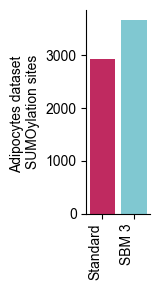

In [14]:
sites_df_org = sites_df[sites_df['Dataset'].isin(['SBM 3', 'Standard'])]
sites_df_org = sites_df_org[~sites_df_org['Leading proteins'].str.startswith(('CON', 'REV'))]

sites_counts = sites_df_org.groupby(['Dataset']).size().reset_index(name='Count')
sites_counts = sites_counts.sort_values(by='Dataset')

count_standard = sites_counts.loc[sites_counts['Dataset'] == 'Standard', 'Count'].values[0]
count_sbm3 = sites_counts.loc[sites_counts['Dataset'] == 'SBM 3', 'Count'].values[0]
percentage_increase = ((count_sbm3 - count_standard) / count_standard) * 100

sites_counts['Dataset'] = pd.Categorical(sites_counts['Dataset'], categories=custom_order, ordered=True)
sites_counts = sites_counts.sort_values('Dataset')

plt.figure(figsize=(1.7, 3))
palette = [color_map[ds] for ds in sites_counts['Dataset']]
ax = sns.barplot(data=sites_counts, x='Dataset', y='Count', palette=palette)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add counts on bars
#for container in ax.containers:
#    ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

plt.xticks(rotation=90, ha='right')
plt.ylabel('Adipocytes dataset \nSUMOylation sites')
plt.xlabel('')
print(f"SBM 3 vs Standard (+{percentage_increase:.1f}%)")
plt.tight_layout()
output_path = fig_dir + "sites.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

In [16]:
big_df = big_df[big_df['Dataset'].isin(['SBM 3', 'Standard'])]

big_df["Modified sequence"] = big_df["Modified sequence"].str.replace(r'\(su\)', '[su]', regex=True).str.replace(r'_', '', regex=True).str.replace(r'\(Acetyl \(Protein N-term\)\)', '', regex=True).str.replace(r'\(Oxidation \(M\)\)', '', regex=True)     # (Oxidation (M))

big_df = big_df[big_df['Reverse'] != '+']

all_counts = big_df.groupby('Dataset').size()

df_sumo = big_df[big_df['SUMO2/3-DVFQQQTGG'] == 1]
df_no_sumo = big_df[big_df['SUMO2/3-DVFQQQTGG'] == 0]

df_sumo_unique = df_sumo.groupby('Dataset').apply(
    lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='first')
).reset_index(drop=True)


sumo_counts = df_sumo.groupby('Dataset').size()
unique_sumo_counts = df_sumo_unique.groupby('Dataset').size()

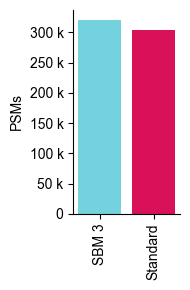

In [17]:
fig, ax_psms = plt.subplots(figsize=(2,3))

psm_bars = ax_psms.bar(
    all_counts.index,
    all_counts.values,
    color=[color_map.get(dataset, 'grey') for dataset in all_counts.index]
)

ax_psms.set_xlabel('')
ax_psms.set_ylabel('PSMs')
ax_psms.set_title('')
ax_psms.set_xticks(range(len(all_counts.index)))
ax_psms.set_xticklabels(all_counts.index, rotation=90)
ax_psms.spines['right'].set_visible(False)
ax_psms.spines['top'].set_visible(False)
ax_psms.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
output_path = fig_dir + "nr_psms_adipocytes.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

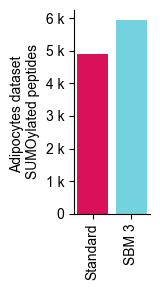

In [18]:
fig, ax = plt.subplots(figsize=(1.7, 3))
unique_sumo_counts = unique_sumo_counts.reindex(custom_order)
bars = ax.bar(unique_sumo_counts.index, unique_sumo_counts.values, 
    color=[color_map.get(dataset, 'grey') for dataset in unique_sumo_counts.index]
)

#for bar in bars:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('')
ax.set_ylabel('Adipocytes dataset \nSUMOylated peptides')
ax.set_title('')
ax.set_xticks(unique_sumo_counts.index) 
ax.set_xticklabels(unique_sumo_counts.index, rotation=90) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "nr_sumoylated_peptides_adipocytes.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

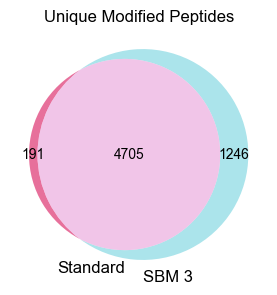

In [19]:
datasets = df_sumo_unique['Dataset'].unique()

datasets = sorted(datasets, key=lambda d: list(color_map.keys()).index(d)) 
sequence_sets = {
    ds: set(df_sumo_unique[df_sumo_unique['Dataset'] == ds]['Modified sequence'])
    for ds in datasets
}

set_colors = [color_map[ds] for ds in datasets]

plt.figure(figsize=(3, 3))

if len(sequence_sets) == 2:
    venn2(subsets=sequence_sets.values(), set_labels=sequence_sets.keys(), set_colors=set_colors, alpha=0.6)
elif len(sequence_sets) == 3:
    venn3(subsets=sequence_sets.values(), set_labels=sequence_sets.keys(), set_colors=set_colors, alpha=0.6)
else:
    print("Venn diagram supports only 2 or 3 datasets.")

plt.title("Unique Modified Peptides")
plt.tight_layout()
file_path = fig_dir + "venn_adipocytes.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

In [20]:
df_sumo_unique_w_uniprot = process_data_msms_MQ(df_sumo_unique, species = 'mouse') # custom function see protein_inference.py

/Users/hmt128/miniconda3/lib/python3.11/site-packages/biotite/sequence/io/fasta/convert.py:248: UserWarning: ProteinSequence objects do not support selenocysteine (U), occurrences were substituted by cysteine (C)
  warnings.warn(


In [25]:
dataset_names = df_sumo_unique_w_uniprot['Dataset'].unique()

dataset_sequence_sets = {
    name: set(df_sumo_unique_w_uniprot[df_sumo_unique_w_uniprot['Dataset'] == name]['Gene_name'])
    for name in dataset_names
}

unique_gene_names_per_dataset = {
    name: gene_set - set.union(*(s for n, s in dataset_sequence_sets.items() if n != name))
    for name, gene_set in dataset_sequence_sets.items()
}


In [32]:
# These are the genes used at input for STRING network. Shown in the supplementary material

for gene in unique_gene_names_per_dataset['SBM 3']:
    print(gene)

Ccdc71
Sec24d
Hmbs
Dhx38
Smarca2
Ddx5
Snrpe
Wac
Supt3
Mical1
C1rb
Pygo2
Ifi35
Ppil2
Nudt9
Snrpa
Ncbp3
Hmces
Timm44
Vps4b
Osbpl9
Arpc3
Sumf2
Npat
Ap3d1
Xdh
Usp28
Eif5a
Esyt2
Cdk11b
Ninl
Lamb1
Zxdc
Gar1
Uqcrfs1
Pabpc1
Dynll2
Efl1
Wdr33
Ctdspl2
Gga2
Supt16
Mvp
Mtap
Eif4ebp1
Macf1
Thoc2
Mycbp2
Afg1l
Pcna
Creb1
Ubr7
Nup88
Zfp870
Gabre
Mlxip
Nfrkb
Cnot1
Rpl22l1
Ezh2
Gcn1
Rpp30
Herc1
Dync1h1
Klf10
Ccdc14
Llph
Ppp1r2
Sec23ip
Rps6
Cfap36
Rbm8a
Xrcc1
Itpa
Anapc7
Acacb
Fam114a2
Septin5
Ppp1cb
Mpst
Noc3l
Nhp2
Golgb1
Plpbp
Xrn2
Med13l
Rps28
Cmss1
Rpl24
Calm5
Gtf3c2
Timp2
Nop16
Tfcp2l1
Nudc
Rpl36a
Ywhae
Huwe1
Vat1
Cdca5
Med14
Mcm2
Atp5po
Nme2
Ddx3x
Sugt1
Rpl34
Arhgef2
Hdx
Utp3
Cdca7
Epc1
Arhgap25
Abl1
Mta3
Zfp729b
Stab2
Dynll1
Sbno1
Dnajc13
Psmd7
Taf4b
Snrnp35
Gsto1
Scp2
Psmb5
Dnah7c
Cand1
Zfp563
Colgalt2
Fshr
Plekhg5
Psme2
Med20
Ube4a
Rnps1
Ints2
Etv4
Plagl2
Nsd2
H2bc18
Sem1
Cdk13
Arhgap1
Hist1h2bp
Trim7
Tbl2
Abcf3
Rere
Rps15a
Thrsp
Hnrnph1
Xbp1
Ercc6l
Csrp1
Eprs1
Hoxa5
Pdcd4
Actn1
Ik
Utp14b
Meis3


In [33]:
for gene in unique_gene_names_per_dataset['Standard']:
    print(gene)

Kcnj4
Kmt5a
Ubap2l
Ppp1ca
Gtpbp4
Srgap1
Uap1l1
Lrriq3
Yars1
Clip2
Tpp2
Spag9
Usp9x
Aco2
Apex1
Nt5c3a
Aspm
Gm136
Dnah3
Pde4d
Pak2
Dnah11
Mepce
Pycr1
Ccdc136
Fermt2
Ascc3
Znf653
Dcaf8
U2af1
Cetn2
Pam
Pde4b
Parp8
Ank2
Ccdc88a
Slc25a22
Zbtb14
Cdc42ep5
Rdx
Rps13
Cct6a
Xpo1
Prkg1
Kif16b
Spc25
Eif3c
Bmp2k
Rfc2
Smc4
Max
Cdk4
Ankar
Ndufs3
Rbm47
Abcb1a
Semg1
